In [1]:
import pandas as pd 
import numpy as np 
import seaborn as sns 
import matplotlib.pyplot as plt 

In [2]:
path=r"C:\Users\sajid\OneDrive\Desktop\Sentiment_Analaysis(project)\Data\Combined Data.csv"
df=pd.read_csv(path)
df.head()

,Unnamed: 0,statement,status
0,0,oh my gosh,Anxiety
1,1,"trouble sleeping, confused mind, restless hear...",Anxiety
2,2,"All wrong, back off dear, forward doubt. Stay ...",Anxiety
3,3,I've shifted my focus to something else but I'...,Anxiety
4,4,"I'm restless and restless, it's been a month n...",Anxiety


In [3]:
df.isnull().sum()

Unnamed: 0      0
statement     362
status          0
dtype: int64

In [4]:
df.duplicated().sum()

np.int64(0)

In [5]:
df=df.drop("Unnamed: 0",axis=1)

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 53043 entries, 0 to 53042
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   statement  52681 non-null  str  
 1   status     53043 non-null  str  
dtypes: str(2)
memory usage: 828.9 KB


In [7]:
df=df.dropna(subset="statement",axis=0)

In [12]:
df['statement'].isnull().sum()

np.int64(0)

In [8]:
df['status'].nunique()

7

In [9]:
df['status'].value_counts()

status
Normal                  16343
Depression              15404
Suicidal                10652
Anxiety                  3841
Bipolar                  2777
Stress                   2587
Personality disorder     1077
Name: count, dtype: int64

<Axes: xlabel='status'>

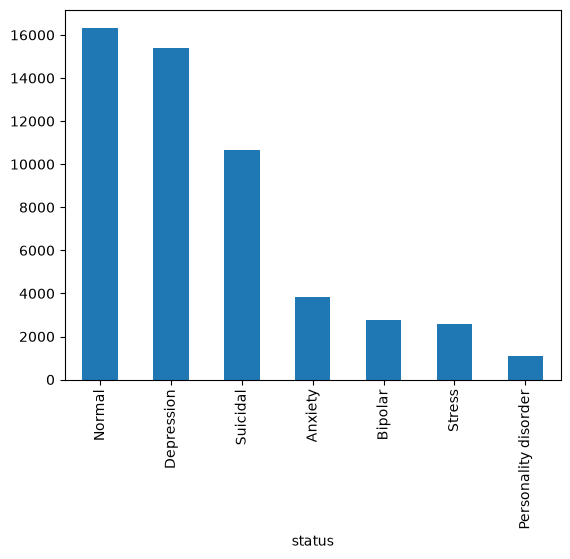

In [10]:
df['status'].value_counts().plot(kind='bar')

In [11]:
import re

df['statement'].str.lower()
df['statement']=df['statement'].apply(lambda x:re.sub(r'[^a-zA-Z0-9\s]','',x))

df['statement']=df['statement'].str.replace(r'\s+', ' ', regex=True).str.split()

In [13]:
from sklearn.model_selection import train_test_split

X = df["statement"]
y = df["status"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [17]:
pip install gensim

  Using cached gensim-4.4.0-cp313-cp313-win_amd64.whl.metadata (8.6 kB)
Using cached gensim-4.4.0-cp313-cp313-win_amd64.whl (24.4 MB)

   ---------------------------------------- 0/3 [wrapt]
   ------------- -------------------------- 1/3 [smart_open]
   ------------- -------------------------- 1/3 [smart_open]
   ------------- -------------------------- 1/3 [smart_open]
   -------------------------- ------------- 2/3 [gensim]
   -------------------------- ------------- 2/3 [gensim]
   -------------------------- ------------- 2/3 [gensim]
   -------------------------- ------------- 2/3 [gensim]
   -------------------------- ------------- 2/3 [gensim]
   -------------------------- ------------- 2/3 [gensim]
   -------------------------- ------------- 2/3 [gensim]
   -------------------------- ------------- 2/3 [gensim]
   -------------------------- ------------- 2/3 [gensim]
   -------------------------- ------------- 2/3 [gensim]
   -------------------------- ------------- 2/3 [gensim]

In [18]:
from gensim.models import Word2Vec

w2v = Word2Vec(
    sentences=X_train.tolist(),
    vector_size=100,
    window=5,
    min_count=2,
    workers=4,
    sg=1,
    epochs=10
)

In [19]:
print(len(w2v.wv))

33183


In [20]:
print(w2v.wv["nervous"])

[-0.10620139  1.0437616  -0.30951607 -0.40138158  0.06310469 -0.49736717
  0.23481397  0.7166615  -0.25411218 -0.31677777  0.0901951  -0.45563307
  0.5865586   0.30006796  0.4025503  -0.24382025  0.20834963 -0.5097853
 -0.11458828 -0.02611187  0.05512126 -0.4198224   0.37719378  0.43710822
 -0.21280211  0.17179821  0.4319956   0.05058099 -0.00607446 -0.05040733
  0.29602528  0.40102464  0.6509376  -0.39010683  0.26305377  0.3765317
  0.40191078 -0.26744407 -0.40296742 -0.46642596 -0.1685281  -0.2546672
 -0.24217986  0.21722545  0.01048193 -0.05834287 -0.2327629   0.07009021
  0.03426867  0.0444561  -0.21535343  0.18745193  0.28979555  0.32429317
 -0.1656158  -0.22235832  0.03849608 -0.09031031  0.03615035 -0.38951248
  0.19048947 -0.7576298  -0.34143016 -0.1382221  -0.2773854   0.37122622
 -0.19781628 -0.09417395  0.02378746  0.37908033  0.04809337  0.03341955
 -0.20983727  0.23846842  0.38308823  0.1696538   0.20169456  0.35418978
 -0.03030126  0.49945417 -0.2899622   0.18711759 -0.51

In [21]:
print(w2v.wv.most_similar("nervous", topn=5))

[('anxious', 0.7974889874458313), ('worried', 0.7168431282043457), ('panicking', 0.6701134443283081), ('paranoid', 0.6598766446113586), ('stressed', 0.6585758328437805)]


In [22]:
import numpy as np

def document_vector(tokens):
    vectors = [
        w2v.wv[word]
        for word in tokens
        if word in w2v.wv
    ]

    if not vectors:
        return np.zeros(w2v.vector_size)

    return np.mean(vectors, axis=0)

In [23]:
X_train_w2v = np.array([
    document_vector(tokens)
    for tokens in X_train
])

X_test_w2v = np.array([
    document_vector(tokens)
    for tokens in X_test
])

In [24]:
print(X_train_w2v.shape)
print(X_test_w2v.shape)

(42144, 100)
(10537, 100)


# Apply Logistic Regression

In [25]:
from sklearn.linear_model import LogisticRegression

lr_w2v = LogisticRegression(
    max_iter=1000,
    class_weight="balanced"
)

lr_w2v.fit(X_train_w2v, y_train)

y_pred_lr = lr_w2v.predict(X_test_w2v)

In [26]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred_lr))

                      precision    recall  f1-score   support

             Anxiety       0.63      0.68      0.66       768
             Bipolar       0.51      0.70      0.59       556
          Depression       0.72      0.52      0.60      3081
              Normal       0.88      0.67      0.76      3269
Personality disorder       0.20      0.71      0.32       215
              Stress       0.32      0.56      0.41       517
            Suicidal       0.60      0.73      0.66      2131

            accuracy                           0.64     10537
           macro avg       0.55      0.65      0.57     10537
        weighted avg       0.70      0.64      0.65     10537



# Linear SVC

In [27]:
from sklearn.svm import LinearSVC

svm_w2v = LinearSVC(
    class_weight="balanced"
)

svm_w2v.fit(X_train_w2v, y_train)

y_pred_svm = svm_w2v.predict(X_test_w2v)

print(classification_report(y_test, y_pred_svm))

                      precision    recall  f1-score   support

             Anxiety       0.63      0.70      0.66       768
             Bipolar       0.51      0.71      0.59       556
          Depression       0.73      0.50      0.60      3081
              Normal       0.83      0.76      0.79      3269
Personality disorder       0.24      0.67      0.35       215
              Stress       0.34      0.48      0.40       517
            Suicidal       0.62      0.71      0.66      2131

            accuracy                           0.65     10537
           macro avg       0.56      0.65      0.58     10537
        weighted avg       0.69      0.65      0.66     10537



# Random Forest

In [28]:
from sklearn.ensemble import RandomForestClassifier

rf_w2v = RandomForestClassifier(
    n_estimators=200,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

rf_w2v.fit(X_train_w2v, y_train)

y_pred_rf = rf_w2v.predict(X_test_w2v)

print(classification_report(y_test, y_pred_rf))

                      precision    recall  f1-score   support

             Anxiety       0.74      0.74      0.74       768
             Bipolar       0.63      0.72      0.67       556
          Depression       0.70      0.62      0.66      3081
              Normal       0.86      0.91      0.88      3269
Personality disorder       0.75      0.48      0.59       215
              Stress       0.52      0.50      0.51       517
            Suicidal       0.63      0.69      0.66      2131

            accuracy                           0.73     10537
           macro avg       0.69      0.66      0.67     10537
        weighted avg       0.73      0.73      0.72     10537



In [29]:
import joblib
import os

os.makedirs("models", exist_ok=True)

joblib.dump(rf_w2v, "models/word2vec_random_forest.pkl")
w2v.save("models/word2vec.model")

In [30]:
os.makedirs("models", exist_ok=True)